# 02 — RFM Scoring & Behavioural Segmentation

**SubscribeIQ — Subscription Intelligence & Retention Engine**

Classic RFM (Recency, Frequency, Monetary) comes from retail, where customers make discrete
purchases. A subscription business has no purchase timestamps, so each dimension uses a proxy:

| Dimension | Proxy | Score direction | Why |
|---|---|---|---|
| **Recency** | `tenure_months` | 5 = longest tenure | **Deliberate adaptation:** reversed from classic RFM (where 5 = most recent purchase). For subscriptions, how *established* a customer is matters more than how recently they joined. |
| **Frequency** | `num_services` | 5 = most services | Breadth of engagement: every active service is an ongoing "purchase". |
| **Monetary** | `total_charges` | 5 = most revenue | Actual billed revenue to date. (`estimated_ltv` is kept separate for the Phase 5 retention matrix.) |

Each dimension is scored 1–5 by quintile (`pd.qcut`), the three scores are standardised, and
KMeans groups customers into behavioural segments. **Churn is not a clustering input.** It is
used only afterwards to describe the segments, so the segments are purely behavioural.

All logic lives in `src/segmentation.py`; this notebook calls it and documents the decisions.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sqlalchemy import text

sys.path.insert(0, str(Path.cwd().parent))
from src.db_connection import get_engine
from src import segmentation as seg

engine = get_engine()

SURFACE, INK, INK_2, GRID, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df", "#c9c8c3"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "text.color": INK,
    "xtick.color": INK_2, "ytick.color": INK_2, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.axisbelow": True, "axes.spines.top": False,
    "axes.spines.right": False, "axes.titleweight": "bold", "axes.titlesize": 12,
    "axes.titlelocation": "left", "font.size": 10, "figure.dpi": 110,
})

raw = seg.load_rfm_inputs(engine)
print(f"{len(raw):,} customers loaded from fact_subscription")
raw.head()

7,043 customers loaded from fact_subscription


,customer_id,tenure_months,num_services,total_charges,monthly_charges,churn
0,0002-ORFBO,9,5,593.30,65.6,False
1,0003-MKNFE,9,4,542.40,59.9,False
2,0004-TLHLJ,4,3,280.85,73.9,True
3,0011-IGKFF,13,6,1237.85,98.0,True
4,0013-EXCHZ,3,4,267.40,83.9,True


## 1. Quintile scoring

In [2]:
scored = seg.score_rfm(raw)

edges = {}
for col, src in [("rfm_recency_score", "tenure_months"),
                 ("rfm_frequency_score", "num_services"),
                 ("rfm_monetary_score", "total_charges")]:
    edges[col] = (scored.groupby(col)[src].agg(["min", "max", "size"])
                  .rename(columns={"size": "customers"}))
    print(f"\n{col}  (source: {src})")
    display(edges[col])


rfm_recency_score  (source: tenure_months)


,min,max,customers
rfm_recency_score,,,
1,0,6,1481
2,7,20,1397
3,21,40,1408
4,41,60,1350
5,61,72,1407



rfm_frequency_score  (source: num_services)


,min,max,customers
rfm_frequency_score,,,
1,1,2,2123
2,3,3,846
3,4,5,1887
4,6,6,908
5,7,9,1279



rfm_monetary_score  (source: total_charges)


,min,max,customers
rfm_monetary_score,,,
1,0.00,265.30,1409
2,265.35,939.70,1408
3,939.80,2043.45,1409
4,2044.75,4469.10,1408
5,4473.00,8684.80,1409


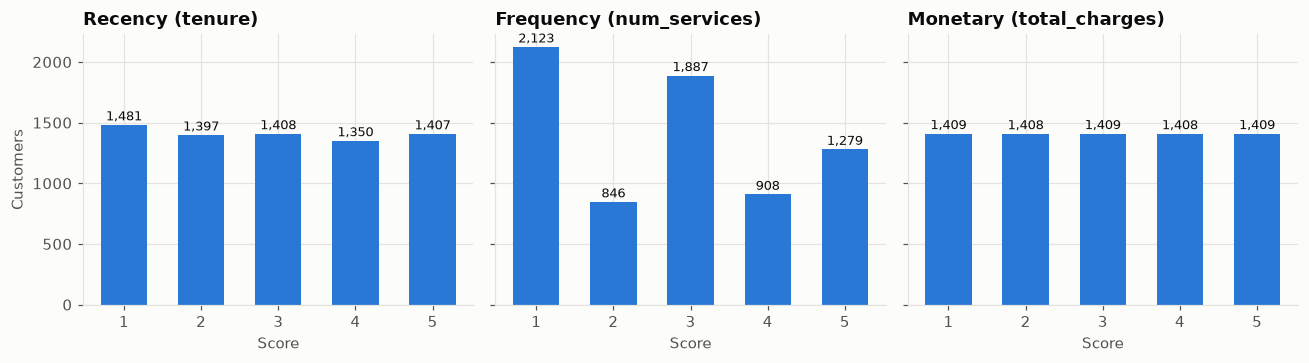

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
titles = ["Recency (tenure)", "Frequency (num_services)", "Monetary (total_charges)"]
for ax, col, title in zip(axes, seg.SCORE_COLUMNS, titles):
    counts = scored[col].value_counts().sort_index()
    bars = ax.bar(counts.index, counts.values, color=BLUE, width=0.6)
    for b in bars:
        ax.annotate(f"{int(b.get_height()):,}", (b.get_x() + b.get_width() / 2, b.get_height()),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8.5)
    ax.set_title(title); ax.set_xlabel("Score"); ax.set_xticks(range(1, 6))
axes[0].set_ylabel("Customers")
fig.tight_layout(); plt.show()

**Reading.** Recency and Monetary split into near-equal quintiles (~1,400 customers each).
Frequency cannot: `num_services` has only 9 distinct values, so the bins are {1–2}, {3}, {4–5},
{6}, {7–9} with uneven sizes. Plain `pd.qcut` was chosen deliberately so that **two customers with
the same number of services always get the same score**. Rank-based binning would force equal
bins but assign different scores to identical customers arbitrarily.

## 2. Known limitation: Monetary overlaps with Recency

,tenure_months,num_services,total_charges,monthly_charges
tenure_months,1.000,0.464,0.890,0.276
num_services,0.464,1.000,0.752,0.853
total_charges,0.890,0.752,1.000,0.638
monthly_charges,0.276,0.853,0.638,1.000


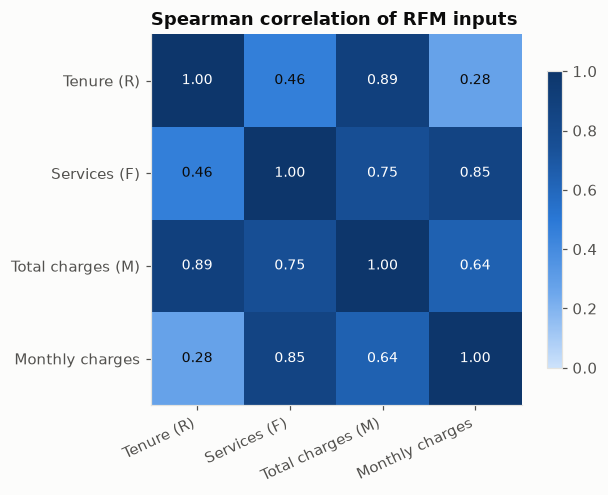

In [4]:
corr = raw[["tenure_months", "num_services", "total_charges", "monthly_charges"]].corr(method="spearman")
display(corr.round(3))

from matplotlib.colors import LinearSegmentedColormap
blues = LinearSegmentedColormap.from_list("seq_blue", ["#cde2fb", "#6da7ec", "#2a78d6", "#184f95", "#0d366b"])
labels = ["Tenure (R)", "Services (F)", "Total charges (M)", "Monthly charges"]
fig, ax = plt.subplots(figsize=(6, 4.6))
im = ax.imshow(corr.values, cmap=blues, vmin=0, vmax=1)
ax.set_xticks(range(4)); ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_yticks(range(4)); ax.set_yticklabels(labels); ax.grid(False)
for i in range(4):
    for j in range(4):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9,
                color="white" if v > 0.55 else INK)
ax.set_title("Spearman correlation of RFM inputs")
fig.colorbar(im, ax=ax, shrink=0.8); fig.tight_layout(); plt.show()

**Reading.** `total_charges` is approximately `monthly_charges × tenure`, so the Monetary input is
**0.89 correlated with Recency**. In practice the M score largely re-measures tenure, and KMeans
effectively gives tenure extra weight. The alternative, `monthly_charges`, would not solve this:
it is 0.85 correlated with Frequency instead. The data really has **two independent behavioural
axes: how long a customer has stayed, and how much they buy each month.**

`total_charges` was kept as the Monetary proxy because it is actual billed revenue, which is the
most defensible "M". Expect the resulting segments to be organised primarily by tenure, with
service breadth as the secondary split.

## 3. Choosing K: elbow, silhouette and stability

,inertia,silhouette,stability_ari,inertia_drop
k,,,,
2,8818.2764,0.4924,0.9130,NaN
3,5865.0813,0.4253,0.9062,2953.1951
4,4134.1908,0.4573,0.9969,1730.8904
5,3190.0272,0.4550,0.9850,944.1637
6,2773.6744,0.4699,0.7367,416.3527
7,2220.6784,0.4722,0.9305,552.9960
8,1943.4340,0.4839,0.8143,277.2444
9,1695.2998,0.5112,0.6817,248.1342
10,1603.4183,0.4949,0.7129,91.8815


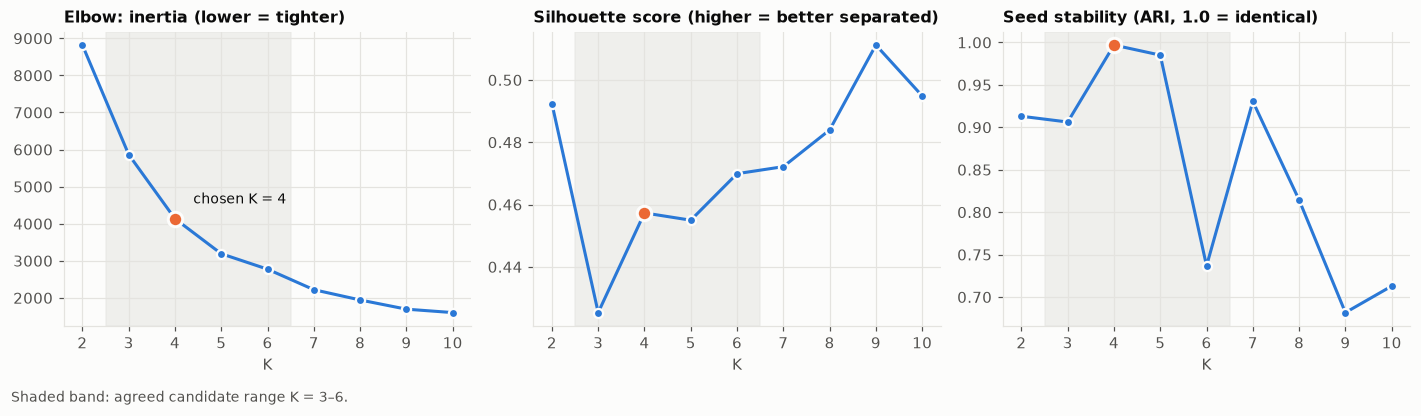

In [5]:
X, scaler = seg.standardize_scores(scored)
diag = seg.evaluate_k(X, k_values=range(2, 11))
diag["inertia_drop"] = -diag["inertia"].diff()
display(diag.round(4))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
ks = diag.index
panels = [("inertia", "Elbow: inertia (lower = tighter)"),
          ("silhouette", "Silhouette score (higher = better separated)"),
          ("stability_ari", "Seed stability (ARI, 1.0 = identical)")]
for ax, (col, title) in zip(axes, panels):
    ax.plot(ks, diag[col], color=BLUE, linewidth=2, marker="o", markersize=6,
            markeredgecolor=SURFACE, markeredgewidth=1.5)
    ax.axvspan(2.5, 6.5, color=GRID, alpha=0.5, zorder=0)
    ax.scatter([4], [diag.loc[4, col]], s=90, color=ORANGE, zorder=3,
               edgecolor=SURFACE, linewidth=2)
    ax.set_title(title, fontsize=10.5); ax.set_xlabel("K"); ax.set_xticks(list(ks))
axes[0].annotate("chosen K = 4", (4, diag.loc[4, "inertia"]), xytext=(12, 10),
                 textcoords="offset points", fontsize=9)
fig.text(0.01, -0.03, "Shaded band: agreed candidate range K = 3–6.", fontsize=9, color=INK_2)
fig.tight_layout(); plt.show()

**Decision: K = 4.** The candidate range K = 3–6 was agreed up front, since K = 2 is too
coarse to act on.

- **Elbow:** inertia drops by 2,953 (K 2→3) and 1,731 (3→4), then only 944 and 416. The
  curve bends at **K = 4–5**.
- **Silhouette:** within the range it is highest at K = 6 (0.470), but K = 4 (0.457) is within
  0.013. Silhouette also keeps rising past the range (0.51 at K = 9) because the standardised
  scores form a coarse grid of only 60 distinct R-F-M combinations. That inflates separation, so
  small silhouette differences are not meaningful here.
- **Stability:** across 5 random seeds, K = 4 finds the same clusters almost every time
  (ARI 0.997). K = 6 does not (ARI 0.74), which rules it out despite its slightly higher
  silhouette: a segmentation whose membership changes with the random seed can't be used to
  run retention campaigns. K = 5 is also stable in this run (0.985).

  **Transparency note:** the stability scores depend on KMeans initialisation and shift with row
  order. An earlier exploratory run (rows in a different order) gave K = 5 an ARI of 0.89, lower
  than shown here. K = 4 was the most stable in both runs. K = 6 was unstable in both.

K = 4 is the only candidate that is at the elbow, the most stable, and within noise of the best
silhouette, so it was chosen.

## 4. Final clustering and segment naming

In [6]:
segmented = seg.segment_customers(raw)
names = seg.name_clusters(segmented)
centroids = segmented.groupby("cluster_label")[seg.SCORE_COLUMNS].mean().round(2)
centroids["segment_name"] = centroids.index.map(names)
centroids

,rfm_recency_score,rfm_frequency_score,rfm_monetary_score,segment_name
cluster_label,,,,
0,1.39,1.80,1.45,New & Uncommitted
1,2.90,3.48,3.51,Flexible Fiber Users
2,4.62,4.43,4.78,Established Power Users
3,3.82,1.17,2.74,Loyal Basics


Names are assigned by **rules on each cluster's average RFM profile**, not by cluster number
(KMeans label numbers are arbitrary and can change between runs):

1. Lowest average Recency → **New & Uncommitted**
2. Of the rest, lowest average Frequency → **Loyal Basics**
3. Of the rest, highest average Recency → **Established Power Users**
4. Remaining cluster → **Flexible Fiber Users**

In [7]:
profile = seg.profile_segments(segmented)

context = pd.read_sql(text("""
    SELECT k.customer_id,
           k.contract_type = 'Month-to-month' AS month_to_month,
           s.internet_service = 'Fiber optic' AS fiber,
           s.internet_service = 'No'          AS no_internet
    FROM dim_contract k JOIN dim_service s USING (customer_id)
"""), engine)
extra = (segmented[["customer_id", "segment_name"]].merge(context, on="customer_id")
         .groupby("segment_name")[["month_to_month", "fiber", "no_internet"]].mean().mul(100).round(1)
         .add_suffix("_pct"))
profile = profile.join(extra)
profile

,customers,avg_recency_score,avg_frequency_score,avg_monetary_score,median_tenure_months,median_services,median_monthly_charges,median_total_charges,churn_rate_pct,share_pct,month_to_month_pct,fiber_pct,no_internet_pct
segment_name,,,,,,,,,,,,,
New & Uncommitted,2420,1.39,1.80,1.45,4.0,3.0,50.55,207.38,42.56,34.36,87.4,36.6,28.0
Flexible Fiber Users,1674,2.90,3.48,3.51,29.0,5.0,83.93,2196.38,32.20,23.77,68.2,59.9,0.0
Established Power Users,1800,4.62,4.43,4.78,64.0,7.0,94.35,5571.35,12.50,25.56,18.3,61.4,0.0
Loyal Basics,1149,3.82,1.17,2.74,45.0,1.0,23.40,1173.35,6.53,16.31,25.0,8.9,73.9


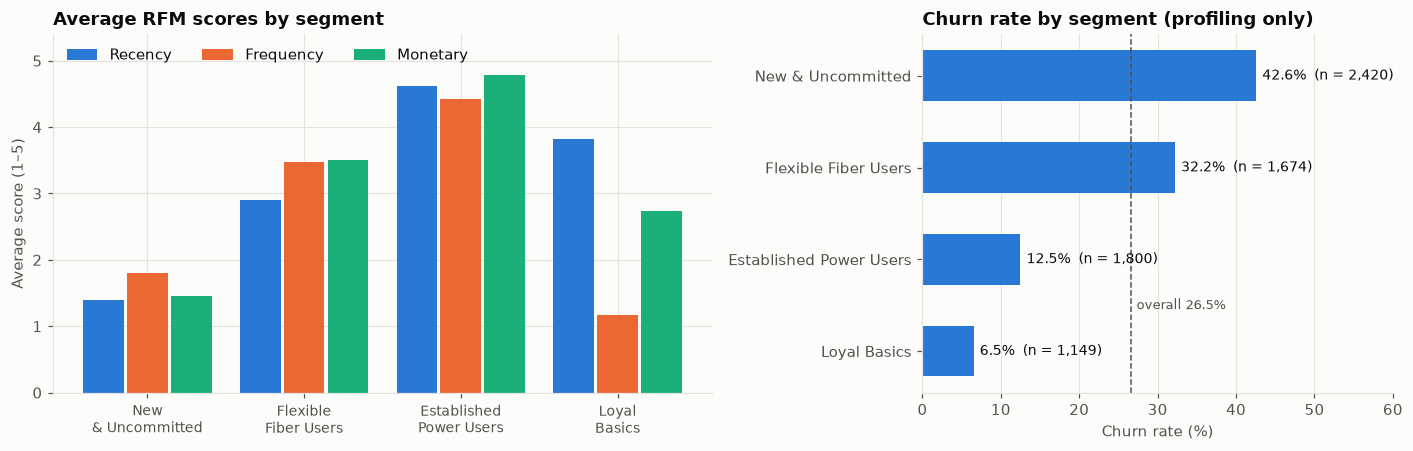

In [8]:
order = profile.index.tolist()   # sorted by churn rate, highest first
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.4, 1]})

ax = axes[0]
w = 0.26
x = np.arange(len(order))
for i, (col, color, name) in enumerate([("avg_recency_score", BLUE, "Recency"),
                                        ("avg_frequency_score", ORANGE, "Frequency"),
                                        ("avg_monetary_score", AQUA, "Monetary")]):
    ax.bar(x + (i - 1) * (w + 0.02), profile.loc[order, col], width=w, color=color, label=name)
ax.set_xticks(x); ax.set_xticklabels([n.replace(" ", "\n", 1) for n in order], fontsize=9)
ax.set_ylim(0, 5.4); ax.set_ylabel("Average score (1–5)")
ax.set_title("Average RFM scores by segment")
ax.legend(frameon=False, ncol=3, loc="upper left")

ax = axes[1]
bars = ax.barh(order[::-1], profile.loc[order[::-1], "churn_rate_pct"], color=BLUE, height=0.55)
for b, n in zip(bars, profile.loc[order[::-1], "customers"]):
    ax.annotate(f"{b.get_width():.1f}%  (n = {n:,})", (b.get_width(), b.get_y() + b.get_height() / 2),
                xytext=(4, 0), textcoords="offset points", va="center", fontsize=9)
ax.axvline(100 * segmented.churn.mean(), color=INK_2, linestyle="--", linewidth=1)
ax.annotate("overall 26.5%", (100 * segmented.churn.mean(), 0.5), xytext=(4, 0), va="center",
            textcoords="offset points", fontsize=8.5, color=INK_2)
ax.set_xlim(0, 60); ax.set_xlabel("Churn rate (%)")
ax.set_title("Churn rate by segment (profiling only)")
ax.grid(axis="y", visible=False)
fig.tight_layout(); plt.show()

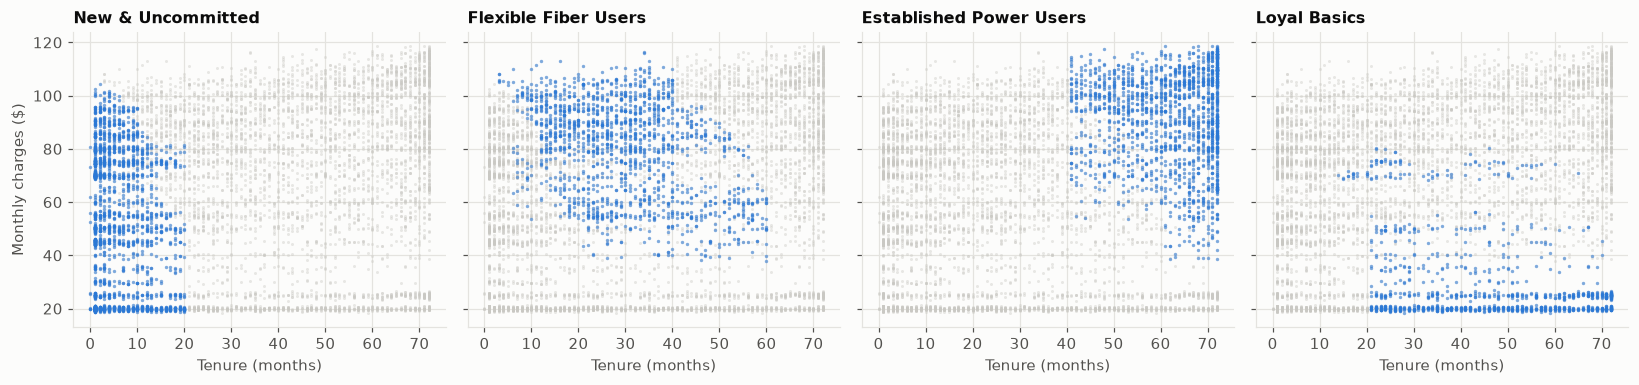

In [9]:
# Where each segment sits in tenure x monthly-charge space (one panel per segment)
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharex=True, sharey=True)
for ax, name in zip(axes, order):
    ax.scatter(segmented.tenure_months, segmented.monthly_charges, s=4, color=MUTED, alpha=0.4,
               linewidths=0)
    sub = segmented[segmented.segment_name == name]
    ax.scatter(sub.tenure_months, sub.monthly_charges, s=5, color=BLUE, alpha=0.55, linewidths=0)
    ax.set_title(name, fontsize=10.5); ax.set_xlabel("Tenure (months)")
axes[0].set_ylabel("Monthly charges ($)")
fig.tight_layout(); plt.show()

## 5. Segment profiles: what each group means for the business

**New & Uncommitted** (2,420 customers, 34%): churn **42.6%**
Median tenure 4 months, 3 services, $51/month, 87% on month-to-month. These customers haven't yet
built a relationship with the provider or committed to it, and the group contains 55% of all
churners. They're the main target for onboarding and first-year engagement. Their low billed revenue so far
means that whether each one is *worth* saving is a Phase 5 question (LTV × risk).

**Flexible Fiber Users** (1,674 customers, 24%): churn **32.2%**
Median tenure 29 months, 5 services, $84/month. The name reflects the defining pattern:
**fiber customers who have stayed flexible**. 68% are still on month-to-month and ~60% are
on fiber optic. Fiber alone doesn't set this group apart: Established Power Users are just
as fiber-heavy (61%) but only 18% month-to-month. Fiber with no long-term contract is the
riskiest product combination found in the EDA. This is a valuable group whose churn rate is
still well above average. They're the best candidates for contract-upgrade offers and
Security/Tech Support bundles.

**Established Power Users** (1,800 customers, 26%): churn **12.5%**
Median tenure 64 months, 7 services, $94/month, 82% on one- or two-year contracts. This group
holds the highest lifetime revenue, so protecting it matters more than growing it.
Loyalty rewards and early access fit better here than discounts.

**Loyal Basics** (1,149 customers, 16%): churn **6.5%**
Median tenure 45 months, 1 service, $23/month. 74% have no internet (phone-only). This group is
very stable but low revenue. The opportunity is careful upselling (e.g. a first internet
service), not retention spend.

**Caveat:** because Monetary overlaps with Recency (section 2), these segments are primarily
*tenure stages* split by service breadth. That is still actionable, but it means segment and tenure
carry overlapping information when both are used as churn-model features in Phase 4.

## 6. Write-back to PostgreSQL

In [10]:
rows = seg.write_segments(engine, segmented)
print(f"customer_segments now holds {rows:,} rows")

pd.read_sql(text("""
    SELECT segment_name,
           COUNT(*)                                          AS customers,
           ROUND(AVG(rfm_recency_score), 2)                  AS avg_r,
           ROUND(AVG(rfm_frequency_score), 2)                AS avg_f,
           ROUND(AVG(rfm_monetary_score), 2)                 AS avg_m,
           ROUND(100 * AVG(f.churn::int), 1)                 AS churn_rate_pct,
           COUNT(churn_probability)                          AS churn_probability_filled,
           COUNT(retention_action)                           AS retention_action_filled
    FROM customer_segments cs
    JOIN fact_subscription f USING (customer_id)
    GROUP BY segment_name
    ORDER BY churn_rate_pct DESC
"""), engine)

customer_segments now holds 7,043 rows


,segment_name,customers,avg_r,avg_f,avg_m,churn_rate_pct,churn_probability_filled,retention_action_filled
0,New & Uncommitted,2420,1.39,1.80,1.45,42.6,0,0
1,Flexible Fiber Users,1674,2.90,3.48,3.51,32.2,0,0
2,Established Power Users,1800,4.62,4.43,4.78,12.5,0,0
3,Loyal Basics,1149,3.82,1.17,2.74,6.5,0,0


The table above is read back **from PostgreSQL**, which confirms the write. `churn_probability`
and `retention_action` remain empty by design; they are filled in Phases 4 and 5.